# <center> Homework 126

In [1]:
import tensorflow_datasets as tfds
from importlib import reload
import tf_data
import tf_model
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_images
import numpy as np
import pandas as pd
from pathlib import Path

2026-02-11 23:36:17.322138: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-11 23:36:17.548610: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-11 23:36:28.288099: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
2026-02-11 23:36:39.854573: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit

## Task 0

метода fit на класа Model да ползва директно Dataset - да има само 1 имплементация

In [65]:
reload(tf_data)
from tf_data import Dataset

train_set, valid_set, test_set = tfds.load(
    name="mnist",
    split=["train[:90%]", "train[90%:]", "test"],
    as_supervised=True
)

train_set, valid_set, test_set = Dataset(train_set), Dataset(valid_set), Dataset(test_set)

train_set = train_set.take(10000).shuffle(buffer_size=1000, seed=42).batch(32).prefetch(1)
valid_set = valid_set.take(1000).batch(32).cache()
test_set = test_set.take(1000).batch(32).cache()
tf.random.set_seed(42)

In [66]:
reload(tf_model)
from tf_model import Sequential, Flatten, Dense, Input

model = Sequential([
    Input([28, 28, 1]),
    Flatten(),
    Dense(10, activation="softmax")
])


model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=5)
test_loss, test_accuracy = model.evaluate(test_set)

Epoch 1/5


0it [00:00, ?it/s]2026-02-12 12:41:55.423129: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


...

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, metric, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2026-02-12 12:42:01.876566: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e29bc092a10 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-02-12 12:42:01.876625: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-02-12 12:42:02.208613: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770892923.280814   29034 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
4it [00:11,  1.87s/it]

5it [00:11,  1.45s/it]

34it [00:38,  1.12s/it]


KeyboardInterrupt: 

## Task 1

да се изготви наивен модел който прави прогноза на броя пътници на база на dataset-a от Chicago Transit Authority.
да работи в следните режими на база:

    деня от седмицата, спрямо предишната седмица
    деня от седмицата, предишния месец
    деня от седмицата, същия месец предишната година
    да се изчисли разликата спрямо предишната годиниа за да се получи stationary time series. да се направи прогноза на тази поредица след които да се добави корекция като се добави обратно величината която е била извадена (както е описано в книгата)

да се оценят и сравнят моделите спрямо следните метрики MAE, MAPE, и MSE

In [ ]:
path = Path("datasets/CTA_-_Ridership_-_Daily_Boarding_Totals_20260211.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1) # no need for total, it's just bus + rail
df = df.drop_duplicates() # remove duplicated months (2011-10 and 2014-07)

In [12]:
df['bus'] = df['bus'].str.replace(",", "").astype(float)
df['rail'] = df['rail'].str.replace(",", "").astype(float)

In [13]:
df.dtypes

day_type     object
bus         float64
rail        float64
dtype: object

In [14]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192.0,126455.0
2001-01-02,W,780827.0,501952.0
2001-01-03,W,824923.0,536432.0
2001-01-04,W,870021.0,550011.0
2001-01-05,W,890426.0,557917.0


In [15]:
df.tail()

,day_type,bus,rail
date,,,
2025-11-26,W,438551.0,301379.0
2025-11-27,U,181164.0,128476.0
2025-11-28,W,347522.0,242928.0
2025-11-29,A,249450.0,206685.0
2025-11-30,U,247697.0,185249.0


<Axes: xlabel='date'>

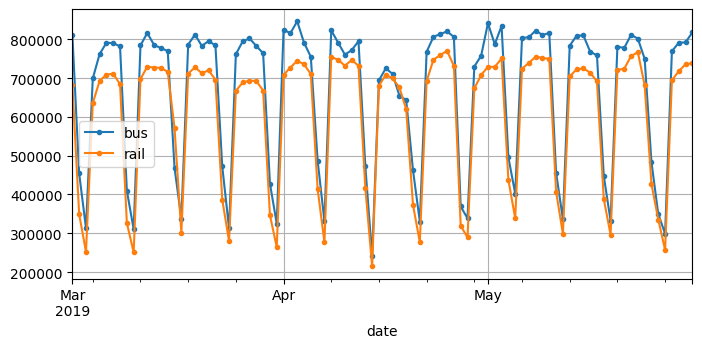

In [16]:
df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))

In [22]:
results = {}
period = slice("2001", "2019")

### деня от седмицата, спрямо предишната седмица

<Axes: xlabel='date'>

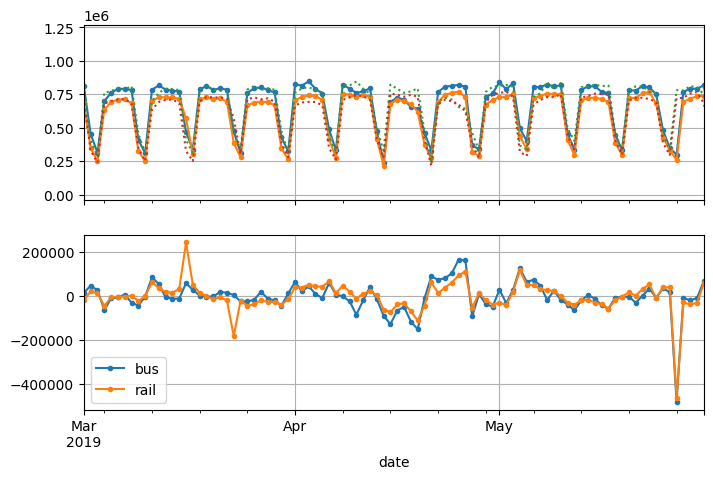

In [107]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

df.plot(ax=axs[0], legend=False, marker=".") 
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]
diff_7.plot(ax=axs[1], grid=True, marker=".")

In [108]:
diff_7 = df[["bus", "rail"]].diff(7)[period]
targets = df[["bus", "rail"]][period]
results['Weekly seasonality'] = {}

results['Weekly seasonality']['MAE'] = diff_7.abs().mean().to_dict()
results['Weekly seasonality']['MAPE'] = (diff_7 / targets).abs().mean().to_dict()
results['Weekly seasonality']['MSE'] = (diff_7 ** 2).mean().to_dict()
results['Weekly seasonality']['MSPE'] = ((diff_7 / targets) ** 2).mean().to_dict()

In [109]:
results['Weekly seasonality']

{'MAE': {'bus': 65848.65493364108, 'rail': 47365.68277553376},
 'MAPE': {'bus': 0.10047382377364682, 'rail': 0.11049073987557922},
 'MSE': {'bus': 15585550356.450665, 'rail': 8611120266.889353},
 'MSPE': {'bus': 0.06905426384075232, 'rail': 0.10489488544520607}}

### деня от седмицата, предишния месец

<Axes: xlabel='date'>

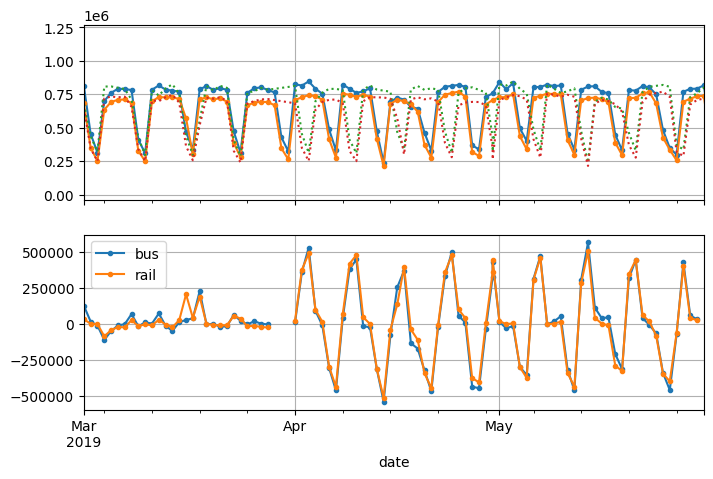

In [110]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

df.plot(ax=axs[0], legend=False, marker=".") 
pred_monthly = df.shift(1, freq=pd.DateOffset(months=1))
pred_monthly.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff_monthly = (df[["bus", "rail"]] - pred_monthly).drop(columns='day_type')
diff_monthly["2019-03":"2019-05"].plot(ax=axs[1], grid=True, marker=".")

In [111]:
diff_monthly = diff_monthly[period]
targets = df[["bus", "rail"]][period]
results['Monthly seasonality'] = {}

results['Monthly seasonality']['MAE'] = diff_monthly.abs().mean().to_dict()
results['Monthly seasonality']['MAPE'] = (diff_monthly / targets).abs().mean().to_dict()
results['Monthly seasonality']['MSE'] = (diff_monthly ** 2).mean().to_dict()
results['Monthly seasonality']['MSPE'] = ((diff_monthly / targets) ** 2).mean().to_dict()

In [112]:
results['Monthly seasonality']

{'MAE': {'bus': 271074.2413144181, 'rail': 205893.48407643312},
 'MAPE': {'bus': 0.43141790847328865, 'rail': 0.4785239620014005},
 'MSE': {'bus': 117767430447.9188, 'rail': 69037021300.5081},
 'MSPE': {'bus': 0.3835037736694568, 'rail': 0.5107376849147968}}

<Axes: xlabel='date'>

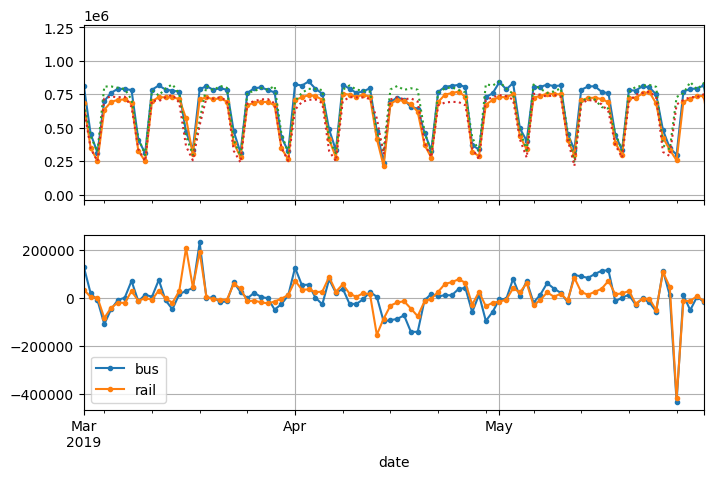

In [113]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

pred_4weeks = df[["bus", "rail"]].shift(28)
diff_4weeks = df[["bus", "rail"]] - pred_4weeks

df.plot(ax=axs[0], legend=False, marker=".") 
pred_4weeks.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff_4weeks["2019-03":"2019-05"].plot(ax=axs[1], grid=True, marker=".")

In [114]:
diff_4weeks = diff_4weeks[period]
targets = df[["bus", "rail"]][period]
results['4 Weeks seasonality'] = {}

results['4 Weeks seasonality']['MAE'] = diff_4weeks.abs().mean().to_dict()
results['4 Weeks seasonality']['MAPE'] = (diff_4weeks / targets).abs().mean().to_dict()
results['4 Weeks seasonality']['MSE'] = (diff_4weeks ** 2).mean().to_dict()
results['4 Weeks seasonality']['MSPE'] = ((diff_4weeks / targets) ** 2).mean().to_dict()

In [115]:
results['4 Weeks seasonality']

{'MAE': {'bus': 78029.06294313414, 'rail': 54746.27694979019},
 'MAPE': {'bus': 0.11768120270620128, 'rail': 0.1244589648040272},
 'MSE': {'bus': 18793453386.48705, 'rail': 10007839062.243092},
 'MSPE': {'bus': 0.07928355630735155, 'rail': 0.10849374329066906}}

### деня от седмицата, същия месец предишната година

<Axes: xlabel='date'>

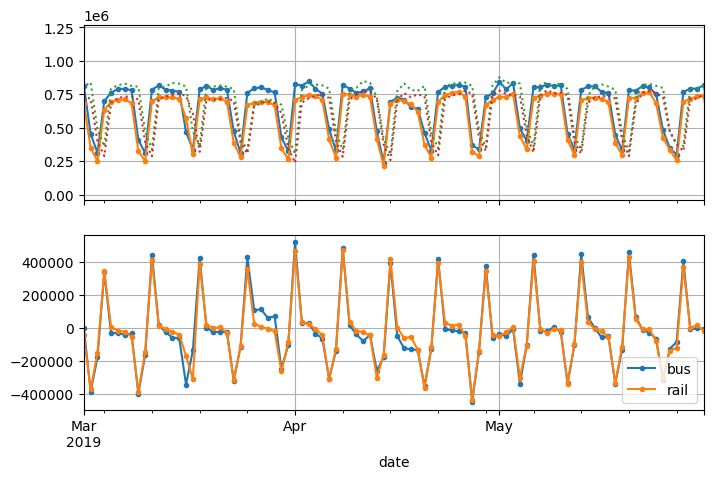

In [116]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

df.plot(ax=axs[0], legend=False, marker=".") 
pred_year = df.shift(1, freq=pd.DateOffset(years=1))
pred_year.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff_year = (df[["bus", "rail"]] - pred_year).drop(columns='day_type')
diff_year["2019-03":"2019-05"].plot(ax=axs[1], grid=True, marker=".")

In [117]:
diff_year = diff_year[period]
targets = df[["bus", "rail"]][period]
results['Year seasonality'] = {}

results['Year seasonality']['MAE'] = diff_year.abs().mean().to_dict()
results['Year seasonality']['MAPE'] = (diff_year / targets).abs().mean().to_dict()
results['Year seasonality']['MSE'] = (diff_year ** 2).mean().to_dict()
results['Year seasonality']['MSPE'] = ((diff_year / targets) ** 2).mean().to_dict()

In [118]:
results['Year seasonality']

{'MAE': {'bus': 198334.2602677213, 'rail': 143322.89899604503},
 'MAPE': {'bus': 0.3042102452206793, 'rail': 0.3151219532372715},
 'MSE': {'bus': 76137804242.50731, 'rail': 42123540623.40645},
 'MSPE': {'bus': 0.20300425865407076, 'rail': 0.2426563864415202}}

### 52 * week = 364

<Axes: xlabel='date'>

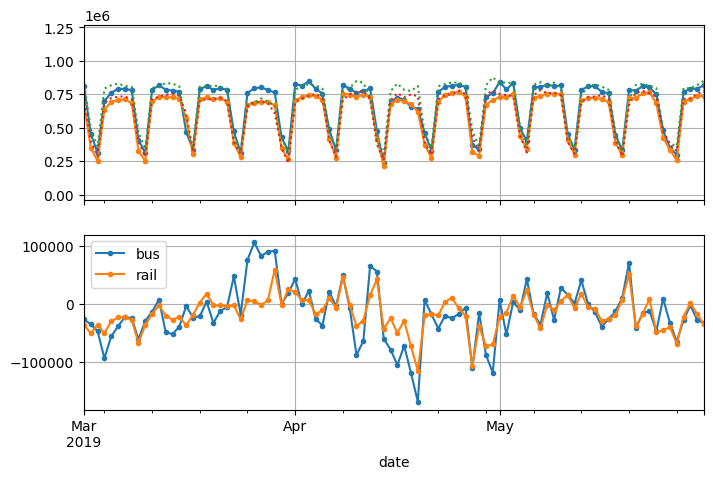

In [119]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

df.plot(ax=axs[0], legend=False, marker=".") 
pred_52weeks = df.shift(52*7) 
pred_52weeks.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff_52weeks = (df[["bus", "rail"]] - pred_52weeks).drop(columns='day_type')
diff_52weeks["2019-03":"2019-05"].plot(ax=axs[1], grid=True, marker=".")

In [120]:
diff_52weeks = diff_52weeks[period]
targets = df[["bus", "rail"]][period]
results['52 Weeks seasonality'] = {}

results['52 Weeks seasonality']['MAE'] = diff_52weeks.abs().mean().to_dict()
results['52 Weeks seasonality']['MAPE'] = (diff_52weeks / targets).abs().mean().to_dict()
results['52 Weeks seasonality']['MSE'] = (diff_52weeks ** 2).mean().to_dict()
results['52 Weeks seasonality']['MSPE'] = ((diff_52weeks / targets) ** 2).mean().to_dict()

In [121]:
results['52 Weeks seasonality']

{'MAE': {'bus': 55511.075133079845, 'rail': 34988.683954372624},
 'MAPE': {'bus': 0.0831686006411921, 'rail': 0.07669884385597374},
 'MSE': {'bus': 8217654628.489582, 'rail': 3798164024.628897},
 'MSPE': {'bus': 0.036663125273655874, 'rail': 0.04147301655799396}}

### да се изчисли разликата спрямо предишната годиниа за да се получи stationary time series. да се направи прогноза на тази поредица след които да се добави корекция като се добави обратно величината която е била извадена (както е описано в книгата)

<Axes: xlabel='date'>

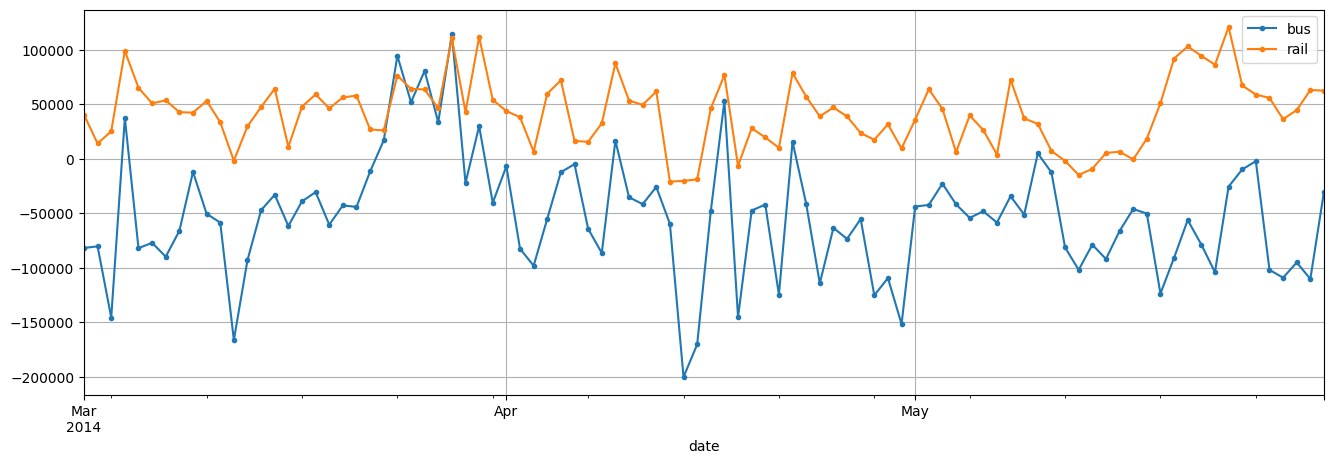

In [122]:
diff_52weeks['2014-03':'2014-05'].plot(grid=True, marker=".", figsize=(16, 5))

<Axes: xlabel='date'>

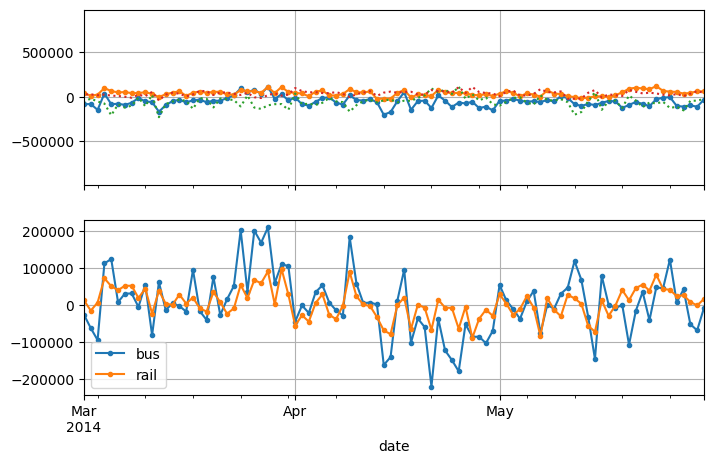

In [123]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

diff_52weeks_pred_monthy = diff_52weeks.shift(28)
diff_diff_52weeks_pred_monthy = diff_52weeks - diff_52weeks_pred_monthy

diff_52weeks.plot(ax=axs[0], legend=False, marker=".") 
diff_52weeks_pred_monthy.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff_diff_52weeks_pred_monthy['2014-03':'2014-05'].plot(ax=axs[1], grid=True, marker=".")

In [124]:
diff_diff_52weeks_pred_monthy = diff_diff_52weeks_pred_monthy[period]
targets = diff_52weeks
results['52Weeks Diff seasonality'] = {}

results['52Weeks Diff seasonality']['MAE'] = diff_diff_52weeks_pred_monthy.abs().mean().to_dict()
results['52Weeks Diff seasonality']['MAPE'] = (diff_diff_52weeks_pred_monthy / targets).abs().mean().to_dict()
results['52Weeks Diff seasonality']['MSE'] = (diff_diff_52weeks_pred_monthy ** 2).mean().to_dict()
results['52Weeks Diff seasonality']['MSPE'] = ((diff_diff_52weeks_pred_monthy / targets) ** 2).mean().to_dict()

In [125]:
results['52Weeks Diff seasonality']

{'MAE': {'bus': 71191.98167099436, 'rail': 46336.7369787689},
 'MAPE': {'bus': 11.865086724377294, 'rail': 5.2320151487551225},
 'MSE': {'bus': 14049559081.188942, 'rail': 6714233207.601497},
 'MSPE': {'bus': 58498.93680299958, 'rail': 1852.7038053905544}}

<Axes: xlabel='date'>

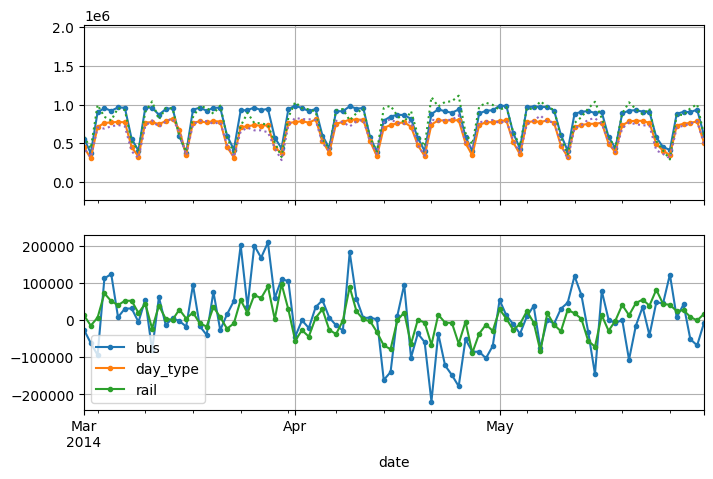

In [126]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

y_hat = diff_52weeks_pred_monthy + df.shift(52*7)
y_hat = y_hat.loc[diff_52weeks_pred_monthy.dropna().index]
real = df.loc[y_hat.index]

diff = real - y_hat

real.plot(ax=axs[0], legend=False, marker=".") 
y_hat.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff['2014-03':'2014-05'].plot(ax=axs[1], grid=True, marker=".")

In [130]:
diff = diff[period].drop(columns='day_type')
targets = real.drop(columns='day_type')
results['Diff Integration'] = {}

results['Diff Integration']['MAE'] = diff.abs().mean().to_dict()
results['Diff Integration']['MAPE'] = (diff / targets).abs().mean().to_dict()
results['Diff Integration']['MSE'] = (diff ** 2).mean().to_dict()
results['Diff Integration']['MSPE'] = ((diff / targets) ** 2).mean().to_dict()

In [131]:
results['Diff Integration']

{'MAE': {'bus': 71191.98167099436, 'rail': 46336.7369787689},
 'MAPE': {'bus': 0.10234640684138535, 'rail': 0.09738024296450891},
 'MSE': {'bus': 14049559081.188942, 'rail': 6714233207.601497},
 'MSPE': {'bus': 0.043225945999986005, 'rail': 0.04736258728857363}}

### да се оценят и сравнят моделите спрямо следните метрики MAE, MAPE, и MSE

In [141]:
res = pd.DataFrame(results)

final = []
for col in res:
    final.append(pd.DataFrame(res[col].to_dict()))

df = pd.concat(final)
inxs_0 = res.columns.repeat(2).values
multi = pd.MultiIndex.from_arrays([inxs_0, df.index])
df.index = multi

df

MAE       MAPE           MSE  \
Weekly seasonality       bus    65848.654934   0.100474  1.558555e+10   
                         rail   47365.682776   0.110491  8.611120e+09   
Monthly seasonality      bus   271074.241314   0.431418  1.177674e+11   
                         rail  205893.484076   0.478524  6.903702e+10   
4 Weeks seasonality      bus    78029.062943   0.117681  1.879345e+10   
                         rail   54746.276950   0.124459  1.000784e+10   
Year seasonality         bus   198334.260268   0.304210  7.613780e+10   
                         rail  143322.898996   0.315122  4.212354e+10   
52 Weeks seasonality     bus    55511.075133   0.083169  8.217655e+09   
                         rail   34988.683954   0.076699  3.798164e+09   
52Weeks Diff seasonality bus    71191.981671  11.865087  1.404956e+10   
                         rail   46336.736979   5.232015  6.714233e+09   
Diff Integration         bus    71191.981671   0.102346  1.404956e+10   
                         rail   46336.736979   0.097380  6.714233e+09   

                                       MSPE  
Weekly seasonality       bus       0.069054  
                         rail      0.104895  
Monthly seasonality      bus       0.383504  
                         rail      0.510738  
4 Weeks seasonality      bus       0.079284  
                         rail      0.108494  
Year seasonality         bus       0.203004  
                         rail      0.242656  
52 Weeks seasonality     bus       0.036663  
                         rail      0.041473  
52Weeks Diff seasonality bus   58498.936803  
                         rail   1852.703805  
Diff Integration         bus       0.043226  
                         rail      0.047363

## Task 2

да се изготви модел който прави прогноза на броя пътници на база на dataset-a от Chicago Transit Authority с помощта на SimpleRNN

да се изислят следните метрики - MAE, MAPE, и MSE

In [47]:
path = Path("datasets/CTA_-_Ridership_-_Daily_Boarding_Totals_20260211.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1) # no need for total, it's just bus + rail
df = df.drop_duplicates() # remove duplicated months (2011-10 and 2014-07)

df['bus'] = df['bus'].str.replace(",", "").astype(float)
df['rail'] = df['rail'].str.replace(",", "").astype(float)

In [20]:
df = df.to_numpy()
df[df[:, 0] == 'W', 0] = 0
df[df[:, 0] == 'A', 0] = 1
df[df[:, 0] == 'U', 0] = 2

onehot = np.zeros((len(df), 3))
onehot[np.arange(len(onehot)), df[:, 0].astype(int)] = 1
encoded_df = np.concatenate([df[:, 1:], onehot], axis=1).astype(float)

In [21]:
encoded_df[:5]

array([[2.97192e+05, 1.26455e+05, 0.00000e+00, 0.00000e+00, 1.00000e+00],
       [7.80827e+05, 5.01952e+05, 1.00000e+00, 0.00000e+00, 0.00000e+00],
       [8.24923e+05, 5.36432e+05, 1.00000e+00, 0.00000e+00, 0.00000e+00],
       [8.70021e+05, 5.50011e+05, 1.00000e+00, 0.00000e+00, 0.00000e+00],
       [8.90426e+05, 5.57917e+05, 1.00000e+00, 0.00000e+00, 0.00000e+00]])

In [34]:
num_data, encoded_data = encoded_df[:, :2], encoded_df[:, 2:]

In [23]:
num_data[:5]

array([[297192., 126455.],
       [780827., 501952.],
       [824923., 536432.],
       [870021., 550011.],
       [890426., 557917.]])

In [24]:
encoded_data[:5]

array([[0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [35]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_scaled_data = scaler.fit_transform(num_data)

In [36]:
prep_data = np.concatenate([num_scaled_data, encoded_data], axis=1)
prep_data[:5]

array([[0.19130771, 0.09164164, 0.        , 0.        , 1.        ],
       [0.61884585, 0.42601953, 1.        , 0.        , 0.        ],
       [0.65782716, 0.45672377, 1.        , 0.        , 0.        ],
       [0.69769424, 0.46881579, 1.        , 0.        , 0.        ],
       [0.71573246, 0.47585603, 1.        , 0.        , 0.        ]])

In [27]:
len(encoded_df)

9100

In [37]:
frame_len = 90

X_train, y_train = [], []
for i in range(7000 - frame_len):
    start = i
    end = i + frame_len
    
    X_train.append(prep_data[start:end])
    y_train.append(num_scaled_data[end])

X_valid, y_valid = [], []
for i in range(7000, 8000 - frame_len):
    start = i
    end = i + frame_len
    
    X_valid.append(prep_data[start:end])
    y_valid.append(num_scaled_data[end])

X_test, y_test = [], []
for i in range(8000, len(prep_data) - frame_len):
    start = i
    end = i + frame_len
    
    X_test.append(prep_data[start:end])
    y_test.append(num_scaled_data[end])

In [38]:
X_train = tf.convert_to_tensor(X_train)
y_train = tf.convert_to_tensor(y_train)

X_valid = tf.convert_to_tensor(X_valid)
y_valid = tf.convert_to_tensor(y_valid)

X_test = tf.convert_to_tensor(X_test)
y_test = tf.convert_to_tensor(y_test)

In [39]:
X_train.shape

TensorShape([6910, 90, 5])

In [49]:
rnn = tf.keras.models.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=X_train.shape[1:]),
    tf.keras.layers.Dense(2)
])

rnn.compile(loss=tf.keras.losses.Huber(), optimizer='adam', metrics=['mse', 'mae', 'mape'])

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
callbacks = [tf.keras.callbacks.EarlyStopping(patience=20)]

rnn.fit(X_train, y_train,
        epochs=200, batch_size=32,
        validation_data=(X_valid, y_valid),
        callbacks=callbacks)

Epoch 1/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1076 - mae: 0.3169 - mape: 73.0637 - mse: 0.2382 - val_loss: 0.3965 - val_mae: 0.8371 - val_mape: 60.8089 - val_mse: 0.8174
Epoch 2/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0464 - mae: 0.1887 - mape: 53.5218 - mse: 0.1060 - val_loss: 0.3138 - val_mae: 0.7269 - val_mape: 53.2295 - val_mse: 0.6387
Epoch 3/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0431 - mae: 0.1764 - mape: 49.1768 - mse: 0.0988 - val_loss: 0.2695 - val_mae: 0.6590 - val_mape: 48.5462 - val_mse: 0.5460
Epoch 4/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0419 - mae: 0.1725 - mape: 48.0432 - mse: 0.0962 - val_loss: 0.2448 - val_mae: 0.6231 - val_mape: 45.9455 - val_mse: 0.4951
Epoch 5/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0408 - mae: 0.1669 - mape: 47.9772 - mse: 0.0936 - val_loss: 0.2405 - val_mae: 0.6089 - val_mape: 44.9076 - val_mse: 0.4873
Epoch 6/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss:

In [53]:
rnn.evaluate(X_test, y_test)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0981 - mae: 0.3463 - mape: 125.3124 - mse: 0.1999


[0.09812837094068527,
 0.1998538076877594,
 0.3463429808616638,
 125.31238555908203]

In [40]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=X_train.shape[1:]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(2)  
])

model.compile(loss='mae', optimizer='adam', metrics=['mape', 'mae', 'mse'])

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
callbacks = [tf.keras.callbacks.EarlyStopping(patience=20, monitor='val_loss', restore_best_weights=True)]

model.fit(X_train, y_train,
        epochs=200, batch_size=64,
        validation_data=(X_valid, y_valid),
        callbacks=callbacks)

Epoch 1/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - loss: 0.0348 - mae: 0.0348 - mape: 9.3808 - mse: 0.0045 - val_loss: 0.0892 - val_mae: 0.0892 - val_mape: 264328.0000 - val_mse: 0.0126
Epoch 2/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - loss: 0.0346 - mae: 0.0346 - mape: 9.2887 - mse: 0.0045 - val_loss: 0.0904 - val_mae: 0.0904 - val_mape: 276522.8438 - val_mse: 0.0131
Epoch 3/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 0.0349 - mae: 0.0349 - mape: 9.3278 - mse: 0.0045 - val_loss: 0.0874 - val_mae: 0.0874 - val_mape: 274444.5312 - val_mse: 0.0133
Epoch 4/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 0.0347 - mae: 0.0347 - mape: 9.2238 - mse: 0.0044 - val_loss: 0.0815 - val_mae: 0.0815 - val_mape: 246407.1875 - val_mse: 0.0112
Epoch 5/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - loss: 0.0341 - mae: 0.0341 - mape: 9.1572 - mse: 0.0044 - val_loss: 0.0779 - val_mae: 0.0779 - val_mape: 252111.1406 - val_mse: 0.0105
Epoch 6/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 

In [43]:
model.evaluate(X_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0598 - mae: 0.0598 - mape: 22.3407 - mse: 0.0060


[0.05977160111069679,
 22.340736389160156,
 0.05977160111069679,
 0.005984732415527105]

In [44]:
y_hat = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step


In [46]:
y_hat = scaler.inverse_transform(y_hat)
y_hat

array([[365086.66 , 120322.96 ],
       [239611.22 , 102249.5  ],
       [559457.06 , 425133.84 ],
       ...,
       [470086.66 , 243770.22 ],
       [340265.06 , 141113.94 ],
       [176444.64 , 124357.125]], shape=(1010, 2), dtype=float32)

In [51]:
real_df = df.iloc[8090:].drop(columns='day_type')

In [52]:
real_df

,bus,rail
date,,
2023-02-25,313877.0,199947.0
2023-02-26,246373.0,152718.0
2023-02-27,438886.0,284156.0
2023-02-28,516342.0,350093.0
2023-03-01,538035.0,357399.0
...,...,...
2025-11-26,438551.0,301379.0
2025-11-27,181164.0,128476.0
2025-11-28,347522.0,242928.0


<Axes: xlabel='date'>

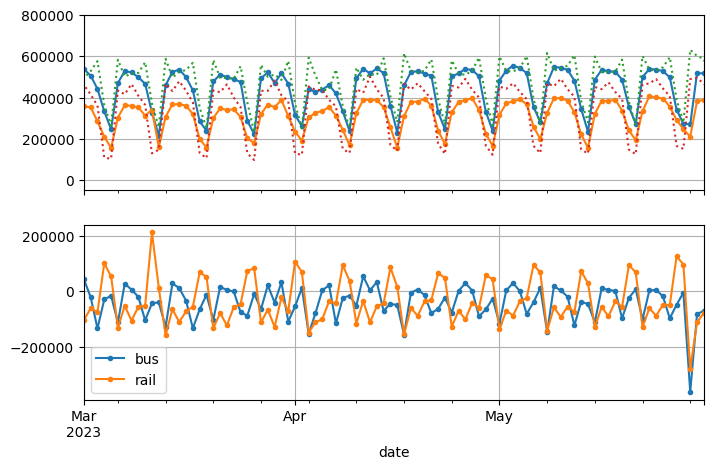

In [53]:
y_hat_df = pd.DataFrame(y_hat, index=real_df.index, columns=real_df.columns)
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

diff = real_df - y_hat_df

real_df.plot(ax=axs[0], legend=False, marker=".") 
y_hat_df.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff['2023-03':'2023-05'].plot(ax=axs[1], grid=True, marker=".")

216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


<Axes: xlabel='date'>

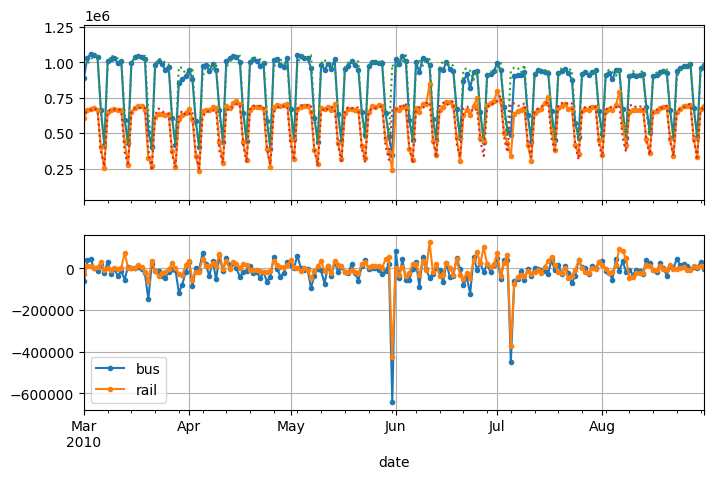

In [55]:
y_hat_train = model.predict(X_train)
y_hat_train = scaler.inverse_transform(y_hat_train)

real_train_df = df.iloc[90:7000].drop(columns='day_type')
y_hat_train_df = pd.DataFrame(y_hat_train, index=real_train_df.index, columns=real_train_df.columns)

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))

diff = real_train_df - y_hat_train_df

real_train_df.plot(ax=axs[0], legend=False, marker=".") 
y_hat_train_df.plot(ax=axs[0], grid=True, legend=False, linestyle=":") 

diff['2010-03':'2010-08'].plot(ax=axs[1], grid=True, marker=".")